In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv(r"C:\Users\Asus\Downloads\reviews_5000.csv")

df.shape

(5000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 4999 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [6]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
3,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...


In [7]:
df.tail()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
4995,370837,B003NZHOQ2,AAFMY4T753D99,markpittsnh,2,3,3,1312329600,Amazing bar! Too expensive @ amazon!,Why is the box of 10 $10 @ Amazon when I can b...
4996,135373,B005VOOM4A,A3H9JSM1SUTE4O,Robin Simmons,1,3,4,1337212800,BOB MARLEY WOULD LIKE THIS I THINK,"I liked the smooth, rather mild flavor of this..."
4997,268329,B0040K41MY,A37PZJH2F13IOR,"J. Rose ""JR From the Ball so Blue""",0,0,5,1340841600,"Tasty, delicious start to your day",Nature's Path is a brand I know and trust. Ver...
4998,29455,B000PDY3P0,A2Q1NU40QODAXT,Tony H,0,0,5,1308614400,Tastes great!,"I have a Waring Pro, and this stuff is fantast..."
4999,266059,B001E96JZG,AN9J46667D80O,"Chris Swanson ""I'm just this guy, you know?""",4,5,5,1224720000,Tasty and filling!,Healthy Choice used to be a byword for mediocr...


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
dtype: int64

In [10]:
df["Summary"].value_counts()

Summary
Yummy!                          20
Delicious!                      19
Delicious                       17
Yummy                           13
Great!                           9
                                ..
Excellent, not at all bitter     1
Works                            1
Cat's Unhappy                    1
Love these but?                  1
Tasty and filling!               1
Name: count, Length: 4581, dtype: int64

In [12]:
df["Summary"].fillna("Yummy",inplace =True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_9212\558357014.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Summary"].fillna("Yummy",inplace =True)


In [13]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [14]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,285336.459600,1.646400,2.115800,4.195800,1.296259e+09
std,165583.018562,5.070711,5.748478,1.303304,4.829051e+07
min,168.000000,0.000000,0.000000,1.000000,1.067904e+09
25%,144814.250000,0.000000,0.000000,4.000000,1.270685e+09
50%,281554.500000,0.000000,1.000000,5.000000,1.311293e+09
75%,430068.500000,2.000000,2.000000,5.000000,1.333238e+09
max,568354.000000,170.000000,171.000000,5.000000,1.351210e+09


In [17]:
df['label'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)


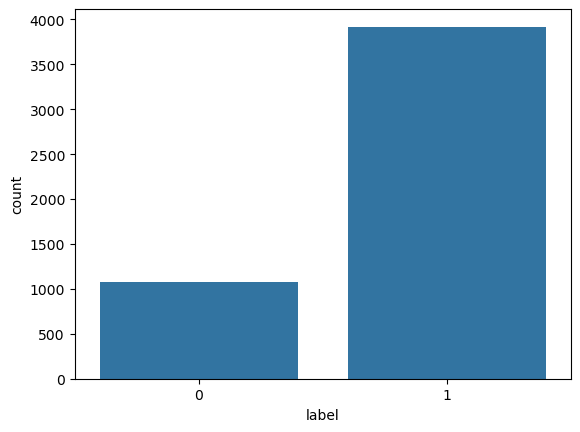

In [16]:
sns.countplot(x='label', data=df)
plt.show()

In [19]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

In [21]:
df['content'] = df['Text'].astype(str)
df['content'] = df['content'].apply(clean_text)

X = df['content']
y = df['label']

In [23]:
tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
X_tfidf = tfidf.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
model = LinearSVC()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.833
              precision    recall  f1-score   support

           0       0.66      0.47      0.55       216
           1       0.86      0.93      0.90       784

    accuracy                           0.83      1000
   macro avg       0.76      0.70      0.72      1000
weighted avg       0.82      0.83      0.82      1000



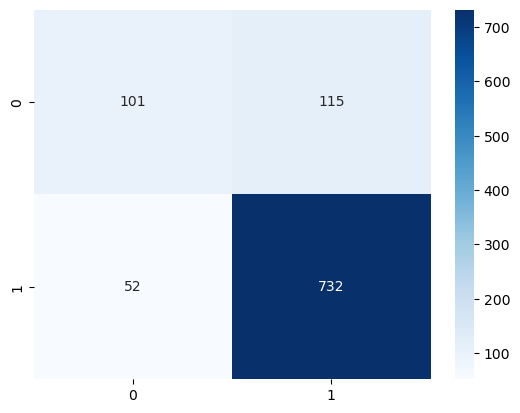

In [26]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [29]:

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': ['balanced', None]}
grid = GridSearchCV(LinearSVC(), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced'}


In [30]:
final_model = grid.best_estimator_

final_pred = final_model.predict(X_test)

print('Final Accuracy:', accuracy_score(y_test, final_pred))
print(classification_report(y_test, final_pred))

Final Accuracy: 0.809
              precision    recall  f1-score   support

           0       0.54      0.72      0.62       216
           1       0.92      0.83      0.87       784

    accuracy                           0.81      1000
   macro avg       0.73      0.78      0.75      1000
weighted avg       0.84      0.81      0.82      1000

